Loading weights from vdsp_weights.npy...


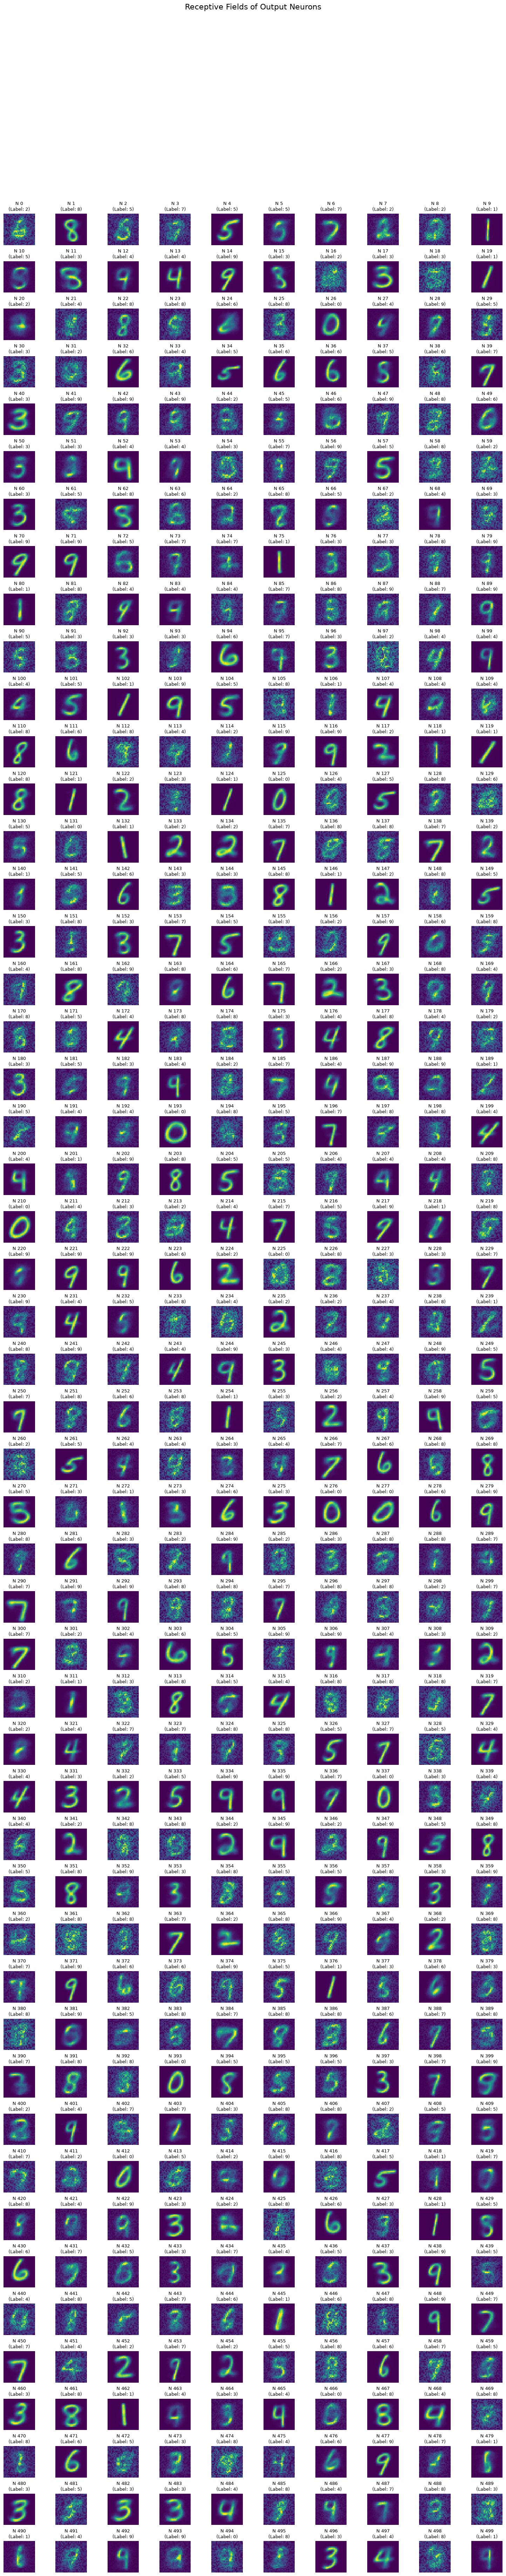

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_receptive_fields(weights_file='vdsp_weights.npy', label_file='assigned_labels.npy'):
    print(f"Loading weights from {weights_file}...")
    
    try:
        # Load the trained weights matrix of shape (784, NUM_OUTPUT)
        weights = np.load(weights_file)
    except FileNotFoundError:
        print(f"Error: The file {weights_file} was not found. Please run the training script first.")
        return

    try:
        # Load the trained weights matrix of shape (784, NUM_OUTPUT)
        neuron_labels = np.load(label_file)
    except FileNotFoundError:
        print(f"Error: The file {label_file} was not found. Please run the training script first.")
        return

    num_input, num_output = weights.shape
    
    # Assuming the input is a square image (e.g., 784 -> 28x28)
    image_size = int(np.sqrt(num_input))
    
    # Calculate a grid size for plotting (e.g., 50 neurons -> 5 rows, 10 cols)
    cols = min(10, num_output)
    rows = int(np.ceil(num_output / cols))
    
    # Create the figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    fig.suptitle('Receptive Fields of Output Neurons', fontsize=16)
    
    # Flatten axes array for easy iteration, in case of a 2D grid
    if num_output > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for i in range(num_output):
        # Extract the weights for the i-th output neuron and reshape to 28x28
        receptive_field = weights[:, i].reshape(image_size, image_size)
        
        # Plot using 'viridis' to closely match the visual style of the paper's Figure 3C
        axes[i].imshow(receptive_field, cmap='viridis')
        axes[i].axis('off')
        assigned_digit = neuron_labels[i]
        axes[i].set_title(f'N {i}\n(Label: {assigned_digit})', fontsize=9)
        
    # Hide any unused subplots if the grid is larger than NUM_OUTPUT
    for j in range(num_output, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

if __name__ == "__main__":
    #visualize_receptive_fields(weights_file='./weights/vdsp_weights_0.01_1.npy', label_file='./labels/assigned_labels_0.01_1.npy')
    visualize_receptive_fields()